In [1]:
from graphviz import Digraph
import math

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [108]:
class Value:
    def __init__(self, data, _children=(), _op = '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.grad = 0.0
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data = {self.data})"

    def __add__(self, other):
        # This line is added later
        other = other if isinstance(other, Value) else Value(other)
        
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other): # other + self
        return self + other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            # _backward is basically derivative of self**other
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        # This line is added later
        other = other if isinstance(other, Value) else Value(other)
        
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * other**-1

    # This is something not needed, it is a python trick to be able to do
    # a = Value(3.0)
    # 2 * a --> This can be done because of __rmul__
    def __rmul__(self, other):
        return self * other

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        # We have to set this or else it will be 0.
        self.grad = 1.0
        
        for node in reversed(topo):
            node._backward()


In [109]:

import random

class Neuron:

    def __init__(self, nin):
        self.w = [Value(2) for _ in range(nin)] 
        self.b = Value(1) 

    def __call__(self, x):
        assert len(x) == len(self.w), f"Dimension mismatch: Neuron expects {len(self.w)} inputs, got {len(x)}"
        out = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        # out = act.tanh()
        return out





In [110]:
class Layer: 
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        print(f'{x=}')
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

In [111]:
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            print(f'MLP_{x=}')
            x = layer(x)
            print(f'MLP{x=}_')
        return x

In [112]:
x = [2.0, 3.0]
n = Layer(2, 3)
print("Layer 1", n(x))

x = [11.0, 11.0, 11.0]
n = Layer(3, 3)
print("Layer 2", n(x))

x = [67.0, 67.0, 67.0]
n = Layer(3, 1)
print("Layer 3", n(x))

x=[2.0, 3.0]
Layer 1 [Value(data = 11.0), Value(data = 11.0), Value(data = 11.0)]
x=[11.0, 11.0, 11.0]
Layer 2 [Value(data = 67.0), Value(data = 67.0), Value(data = 67.0)]
x=[67.0, 67.0, 67.0]
Layer 3 Value(data = 403.0)


In [113]:
x = [2.0, 3.0]
n = MLP(2, [3, 3, 1])
n(x)

MLP_x=[2.0, 3.0]
x=[2.0, 3.0]
MLPx=[Value(data = 11.0), Value(data = 11.0), Value(data = 11.0)]_
MLP_x=[Value(data = 11.0), Value(data = 11.0), Value(data = 11.0)]
x=[Value(data = 11.0), Value(data = 11.0), Value(data = 11.0)]
MLPx=[Value(data = 67.0), Value(data = 67.0), Value(data = 67.0)]_
MLP_x=[Value(data = 67.0), Value(data = 67.0), Value(data = 67.0)]
x=[Value(data = 67.0), Value(data = 67.0), Value(data = 67.0)]
MLPx=Value(data = 403.0)_


Value(data = 403.0)

In [114]:
xs = [
    [22.0, 33.0]
]
ys = [1.0]
n = MLP(2, [1])
ypred = [n(x) for x in xs]
ypred

MLP_x=[22.0, 33.0]
x=[22.0, 33.0]
MLPx=Value(data = 111.0)_


[Value(data = 111.0)]

In [115]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data = 12100.0)

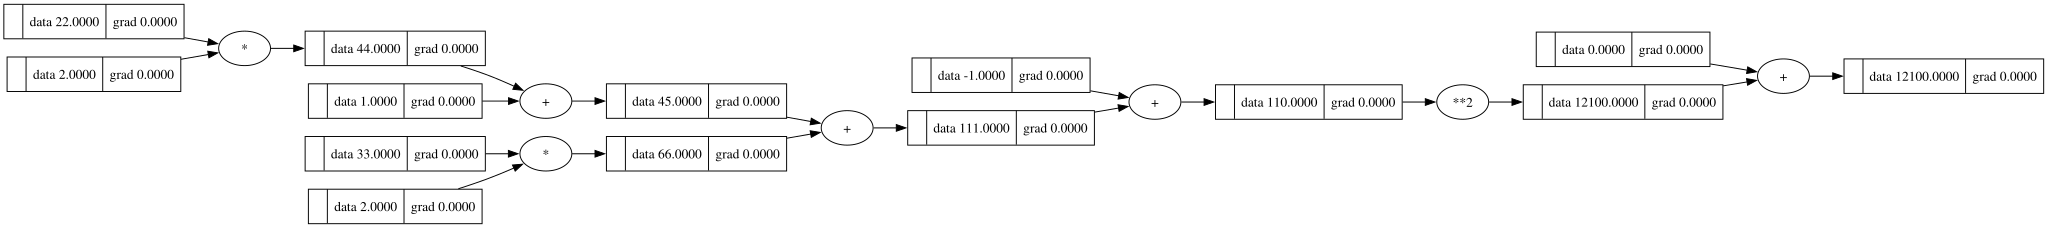

In [116]:
draw_dot(loss)

In [117]:
loss.backward()

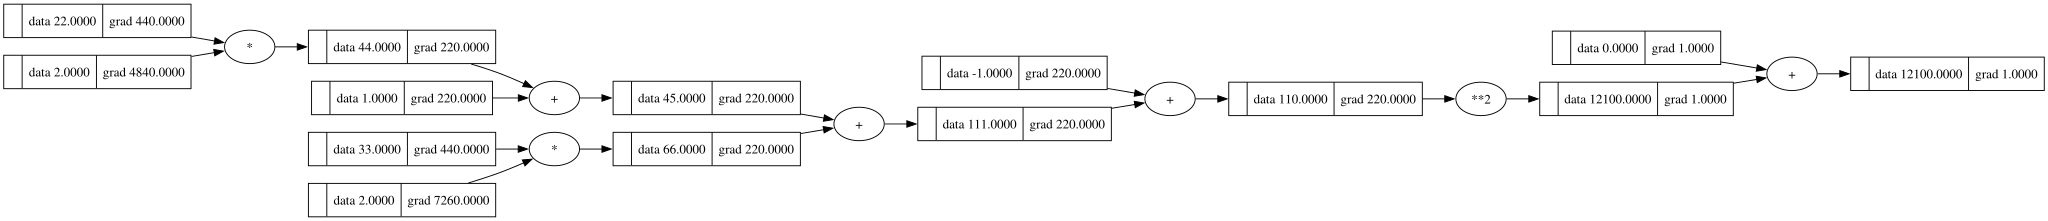

In [118]:
draw_dot(loss)